# Chaper 2 - N-armed Bandits
### Deep Reinforcement Learning _in Action_

In [1]:
import random

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##### Listing 2.1 - Finding the best actions given the expected rewards in Python 3

In [2]:
def exp_reward(action, history):
    """expected reward for taking action (greedy)"""
    rewards_for_action = history[action]
    return sum(rewards_for_action) / len(rewards_for_action)


def get_best_action(actions, history):
    """take the action with maximum expected reward"""
    best_action = 0
    max_action_value = 0
    for i in range(len(actions)):  # A
        cur_action_value = exp_reward(actions[i], history)  # B
        if cur_action_value > max_action_value:
            best_action = i
            max_action_value = cur_action_value
    return best_action

##### Listing 2.2 - Epsilon-greedy strategy for action selection

In [3]:
n = 10  # A
probs = np.random.rand(n)  # B
eps = 0.2  # C

probs

array([0.41323128, 0.72772701, 0.41862407, 0.40243433, 0.8040526 ,
       0.59007811, 0.924833  , 0.50576668, 0.32089689, 0.38661871])

##### Listing 2.3 - Defining the reward function

In [4]:
def get_reward(prob, n=10):
    reward = 0
    for i in range(n):
        if random.random() < prob:
            reward += 1
    return reward

Mean reward: 7.001


(array([  1.,  19.,  80., 213., 381., 543., 460., 239.,  64.]),
 array([ 2.        ,  2.88888889,  3.77777778,  4.66666667,  5.55555556,
         6.44444444,  7.33333333,  8.22222222,  9.11111111, 10.        ]),
 <BarContainer object of 9 artists>)

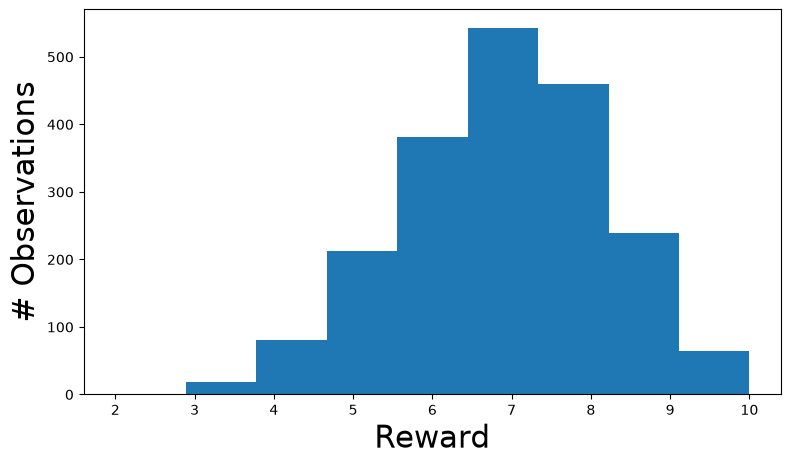

In [5]:
reward_test = [get_reward(0.7) for _ in range(2000)]

print("Mean reward:", np.mean(reward_test))

plt.figure(figsize=(9, 5))
plt.xlabel("Reward", fontsize=22)
plt.ylabel("# Observations", fontsize=22)
plt.hist(reward_test, bins=9)

In [6]:
# Just an expample of sigma
sum = 0
x = [4, 5, 6, 7]
for j in range(len(x)):
    sum = sum + x[j]
sum

22

##### Listing 2.4 - Updating the reward record

In [7]:
# 10 actions x 2 columns
# Columns: Count #, Avg Reward
record = np.zeros((n, 2))

In [8]:
def update_record(record, action, r):
    new_r = (record[action, 0] * record[action, 1] + r) / (record[action, 0] + 1)
    record[action, 0] += 1
    record[action, 1] = new_r
    return record

##### Listing 2.5 - Computing the best action

In [9]:
def get_best_arm(record):
    arm_index = np.argmax(record[:, 1], axis=0)
    return arm_index

##### Listing 2.6 - Solving the n-armed bandit

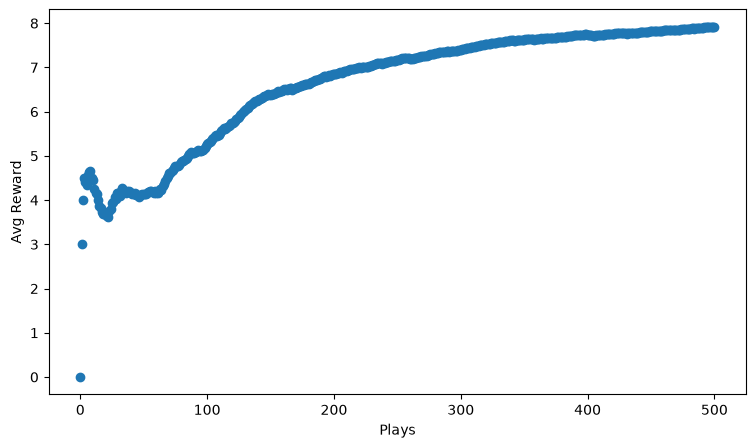

In [10]:
fig, ax = plt.subplots(1, 1)
ax.set_xlabel("Plays")
ax.set_ylabel("Avg Reward")
fig.set_size_inches(9, 5)
rewards = [0]
for i in range(500):
    if random.random() > eps:
        choice = get_best_arm(record)
    else:
        choice = np.random.randint(10)
    r = get_reward(probs[choice])
    record = update_record(record, choice, r)
    mean_reward = ((i + 1) * rewards[-1] + r) / (i + 2)
    rewards.append(mean_reward)
ax.scatter(np.arange(len(rewards)), rewards)

In [11]:
data = []
columns = ["Visit Count", "Average Reward", "Actual Prob"]
for i, (c, avg_r) in enumerate(record):
    data.append((int(c), avg_r, probs[i]))

pd.DataFrame(data=data, columns=columns)

,Visit Count,Average Reward,Actual Prob
0,57,4.350877,0.413231
1,10,6.800000,0.727727
2,9,3.000000,0.418624
3,9,4.000000,0.402434
4,29,7.586207,0.804053
5,11,5.545455,0.590078
6,345,9.211594,0.924833
7,8,4.250000,0.505767
8,8,3.375000,0.320897
9,14,4.500000,0.386619


##### Listing 2.7 - The softmax function

In [12]:
def softmax(av, tau=1.12):
    softm = np.exp(av / tau) / np.sum(np.exp(av / tau))
    return softm

##### Listing 2.8 - Softmax action-selection for the n-armed bandit

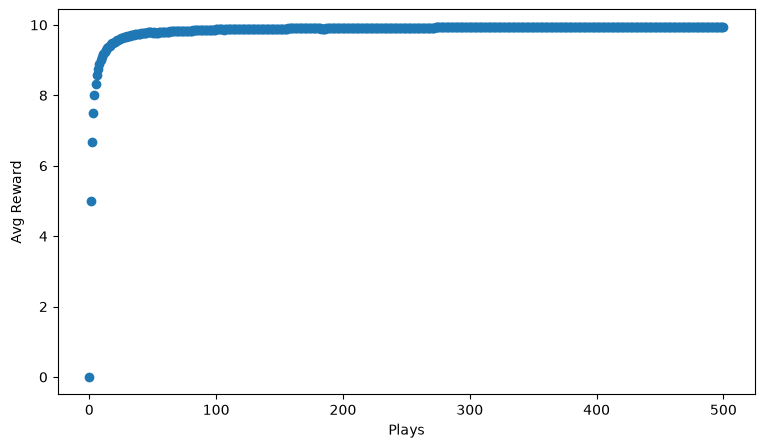

In [13]:
# Reset probs
probs = np.random.rand(n)

# Reset record
record = np.zeros((n, 2))

# Re-run experiment
rewards = [0]
for i in range(500):
    # Play with different tau values
    p = softmax(record[:, 1], tau=0.7)
    # p = softmax(record[:, 1], tau=1.0)
    choice = np.random.choice(np.arange(n), p=p)
    r = get_reward(probs[choice])
    record = update_record(record, choice, r)
    mean_reward = ((i + 1) * rewards[-1] + r) / (i + 2)
    rewards.append(mean_reward)

# Plot
fig, ax = plt.subplots(1, 1)
ax.set_xlabel("Plays")
ax.set_ylabel("Avg Reward")
fig.set_size_inches(9, 5)
ax.scatter(np.arange(len(rewards)), rewards)

In [14]:
data = []
columns = ["Visit Count", "Average Reward", "Actual Prob"]
for i, (c, avg_r) in enumerate(record):
    data.append((int(c), avg_r, probs[i]))

pd.DataFrame(data=data, columns=columns)

,Visit Count,Average Reward,Actual Prob
0,0,0.00,0.297271
1,0,0.00,0.944845
2,0,0.00,0.087069
3,0,0.00,0.254620
4,0,0.00,0.813642
5,0,0.00,0.885683
6,0,0.00,0.424902
7,0,0.00,0.693510
8,500,9.96,0.995256
9,0,0.00,0.504244


##### Section 2.4 Working with PyTorch

In [15]:
np.array([[1, 2, 3], [4, 5, 6]])

array([[1, 2, 3],
       [4, 5, 6]])

In [16]:
torch.Tensor([[1, 2, 3], [4, 5, 6]])

tensor([[1., 2., 3.],
        [4., 5., 6.]])

In [17]:
x = torch.Tensor([2, 4])  # input data
m = torch.randn(2, requires_grad=True)  # parameter 1
b = torch.randn(1, requires_grad=True)  # parameter 2
y = m * x + b  # linear model
y_known = torch.Tensor([5, 9])
loss = (torch.sum(y_known - y)) ** 2  # loss function
loss.backward()  # calculate gradients

# demonstrate gradient descent
print("m:", m)
print("b:", b)
print("Predicted:", y)
print("loss:", loss)
print("m grad:", m.grad)
print("b grad:", b.grad)

lr = 0.01
with torch.no_grad():
    m -= lr * m.grad
    b -= lr * b.grad

print("New m:", m)
print("New b:", b)
y = m * x + b
print("New prediction:", y)
loss = (torch.sum(y_known - y)) ** 2
print("New loss:", loss)

m: tensor([-0.6027,  0.7841], requires_grad=True)
b: tensor([-0.6601], requires_grad=True)
Predicted: tensor([-1.8656,  2.4764], grad_fn=<AddBackward0>)
loss: tensor(179.2712, grad_fn=<PowBackward0>)
m grad: tensor([ -53.5569, -107.1138])
b grad: tensor([-53.5569])
New m: tensor([-0.0672,  1.8553], requires_grad=True)
New b: tensor([-0.1246], requires_grad=True)
New prediction: tensor([-0.2589,  7.2965], grad_fn=<AddBackward0>)
New loss: tensor(48.4749, grad_fn=<PowBackward0>)


##### Listing 2.9 - Contextual bandit environment

In [18]:
class ContextBandit:
    def __init__(self, arms=10):
        self.arms = arms
        self.init_distribution(arms)
        self.update_state()

    def init_distribution(self, arms):
        # Num states = Num Arms to keep things simple
        self.bandit_matrix = np.random.rand(arms, arms)
        # each row represents a state, each column an arm

    def reward(self, prob):
        reward = 0
        for i in range(self.arms):
            if random.random() < prob:
                reward += 1
        return reward

    def get_state(self):
        return self.state

    def update_state(self):
        self.state = np.random.randint(0, self.arms)

    def get_reward(self, arm):
        return self.reward(self.bandit_matrix[self.get_state()][arm])

    def choose_arm(self, arm):
        reward = self.get_reward(arm)
        self.update_state()
        return reward

In [19]:
env = ContextBandit(arms=10)
state = env.get_state()
reward = env.choose_arm(1)
print(state)
print(reward)

0
2


In [20]:
arms = 10
N, D_in, H, D_out = 1, arms, 100, arms
"""
N: Batch size
D_in: Input dimention
H: Hidden dimention
D_out: Output dimention
"""

'\nN: Batch size\nD_in: Input dimention\nH: Hidden dimention\nD_out: Output dimention\n'

In [21]:
model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Linear(H, D_out),
    torch.nn.ReLU(),
)

In [22]:
loss_fn = torch.nn.MSELoss()

In [23]:
env = ContextBandit(arms)

In [24]:
def one_hot(N, pos, val=1):
    one_hot_vec = np.zeros(N)
    one_hot_vec[pos] = val
    return one_hot_vec

In [25]:
def running_mean(x, N=50):
    c = x.shape[0] - N
    y = np.zeros(c)
    conv = np.ones(N)
    for i in range(c):
        y[i] = (x[i : i + N] @ conv) / N
    return y

#### Listing 2.10. The main training loop

In [26]:
def train(env, epochs=10000, learning_rate=1e-3):
    cur_state = torch.Tensor(one_hot(arms, env.get_state()))  # A
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    rewards = []
    for _ in range(epochs):
        y_pred = model(cur_state)  # B
        av_softmax = softmax(y_pred.data.numpy(), tau=2.0)  # C
        av_softmax /= av_softmax.sum()  # D
        choice = np.random.choice(arms, p=av_softmax)  # E
        cur_reward = env.choose_arm(choice)  # F
        one_hot_reward = y_pred.data.numpy().copy()  # G
        one_hot_reward[choice] = cur_reward  # H
        reward = torch.Tensor(one_hot_reward)
        rewards.append(cur_reward)
        loss = loss_fn(y_pred, reward)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        cur_state = torch.Tensor(one_hot(arms, env.get_state()))  # I
    return np.array(rewards)

In [27]:
rewards = train(env)

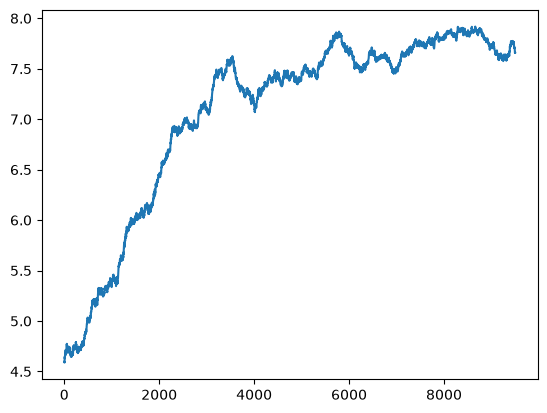

In [28]:
plt.plot(running_mean(rewards, N=500))